# BCR Embedding with scibex — Stephenson 2021 COVID-19 Dataset

This tutorial walks through a complete scibex workflow on the [Stephenson 2021](https://doi.org/10.1038/s41591-021-01329-2) COVID-19 PBMC dataset (5 000 BCR-containing cells):

1. Load a pre-processed scirpy `MuData`
2. Embed heavy- and light-chain CDR3 sequences with **scibex**
3. Visualise the embedding space
4. Train a logistic-regression classifier to predict patient outcome (*Home* vs *Death*)

**scibex** wraps the R [Ibex](https://github.com/BorchLab/Ibex) package and stores results directly in `AnnData.obsm`, following scverse conventions. It operates on the `airr` modality of a scirpy `MuData` — no manual sequence extraction needed.

---

## Prerequisites

```bash
pip install scibex scirpy scanpy muon
```

scibex also requires R with the Ibex package installed. Run the setup cell below. It installs everything and is a no-op if already installed.

In [1]:
import scibex as ib

# Install R dependencies (fast no-op if already installed)
ib.install_r_deps()

All R dependencies already installed.


In [2]:
import warnings

import pandas as pd
import scanpy as sc
import scirpy as ir

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, frameon=False)

## 1. Load the dataset

The dataset is a `MuData` with two modalities:
- **`gex`** — gene expression (pre-processed; PCA/UMAP already computed)
- **`airr`** — BCR contigs in AIRR format, with `obsm["chain_indices"]` already populated by scirpy

In [3]:
mdata = ir.datasets.stephenson2021_5k()
mdata

MuData object with n_obs × n_vars = 5000 × 24929
  2 modalities
    gex:	5000 × 24929
      obs:	'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id'
      var:	'feature_types'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      layers:	'raw'
    airr:	5000 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices', 'scirpy_version'
      obsm:	'airr', 'chain_indices'

In [4]:
mdata["gex"].obs[["Status_on_day_collection_summary", "Outcome"]].value_counts().head(10)

Status_on_day_collection_summary  Outcome
Moderate                          Home       1155
Mild                              Home        949
Critical                          Home        684
Severe                            Home        573
                                  unknown     507
Asymptomatic                      Home        456
Critical                          unknown     265
Severe                            Death       208
Mild                              unknown     203
Name: count, dtype: int64

## 2. Embed BCR sequences with scibex

`ib.tl.ibex` reads CDR3 sequences directly from the scirpy `chain_indices` in the `airr` modality and writes an `[N, D]` embedding array to `mdata["airr"].obsm[key_added]`. Cells that lack a usable chain receive rows filled with **zeros** (the default `fill_value=0.0`; pass `fill_value=float("nan")` to get NaN instead). Pass `verbose=True` to see how many cells were affected.

Available **methods**:

| `method` | `encoder_model` | Description |
| --- | --- | --- |
| `"encoder"` | `"CNN"` | CDR3 convolutional autoencoder |
| `"encoder"` | `"VAE"` | CDR3 variational autoencoder |
| `"encoder"` | `"CNN.EXP"` | CDR1+2+3 CNN (needs `cdr1_aa`/`cdr2_aa` AIRR fields) |
| `"encoder"` | `"VAE.EXP"` | CDR1+2+3 VAE |
| `"geometric"` | — | Fast rule-based geometric transform (BLOSUM62-based) |

Available **`encoder_input`** options: `"atchleyFactors"`, `"kideraFactors"`, `"crucianiProperties"`, `"MSWHIM"`, `"tScales"`, `"OHE"`

For EXP models, `strategy` controls how cells with partial CDR missingness (CDR1 or CDR2 absent but CDR3 present) are handled:
- `"lenient"` (default) — substitute missing CDRs with `"NA"` (Ibex's R convention) and embed anyway
- `"strict"` — any missing CDR → zero row

In [5]:
# Heavy-chain CDR1+2+3 embedding (CNN.EXP with Atchley factors)
# verbose=True reports how many cells lacked complete CDR1/CDR2/CDR3 (filled with zeros)
ib.tl.ibex(
    mdata,
    chain="Heavy",
    method="encoder",
    encoder_model="CNN.EXP",
    encoder_input="atchleyFactors",
    verbose=True,
    key_added="X_ibex_heavy",
)

# Light-chain CDR1+2+3 embedding
ib.tl.ibex(
    mdata,
    chain="Light",
    method="encoder",
    encoder_model="CNN.EXP",
    encoder_input="atchleyFactors",
    verbose=True,
    key_added="X_ibex_light",
)

print("Heavy embedding:", mdata["airr"].obsm["X_ibex_heavy"].shape)
print("Light embedding:", mdata["airr"].obsm["X_ibex_light"].shape)

2026-06-12 17:38:29.602403: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-12 17:38:29.613257: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-12 17:38:29.721076: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-12 17:38:29.827357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781311109.919389  239069 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781311109.94

Heavy embedding: (5000, 128)
Light embedding: (5000, 128)


## 3. Visualise the heavy-chain embedding

We compute a UMAP from the heavy-chain Ibex embedding and colour cells by COVID-19 outcome and clinical status.

> **Note:** `gex` and `airr` are stored with different cell orderings in this `MuData`. We reindex the embeddings to the `gex` cell ordering via barcode before handing off to scanpy.

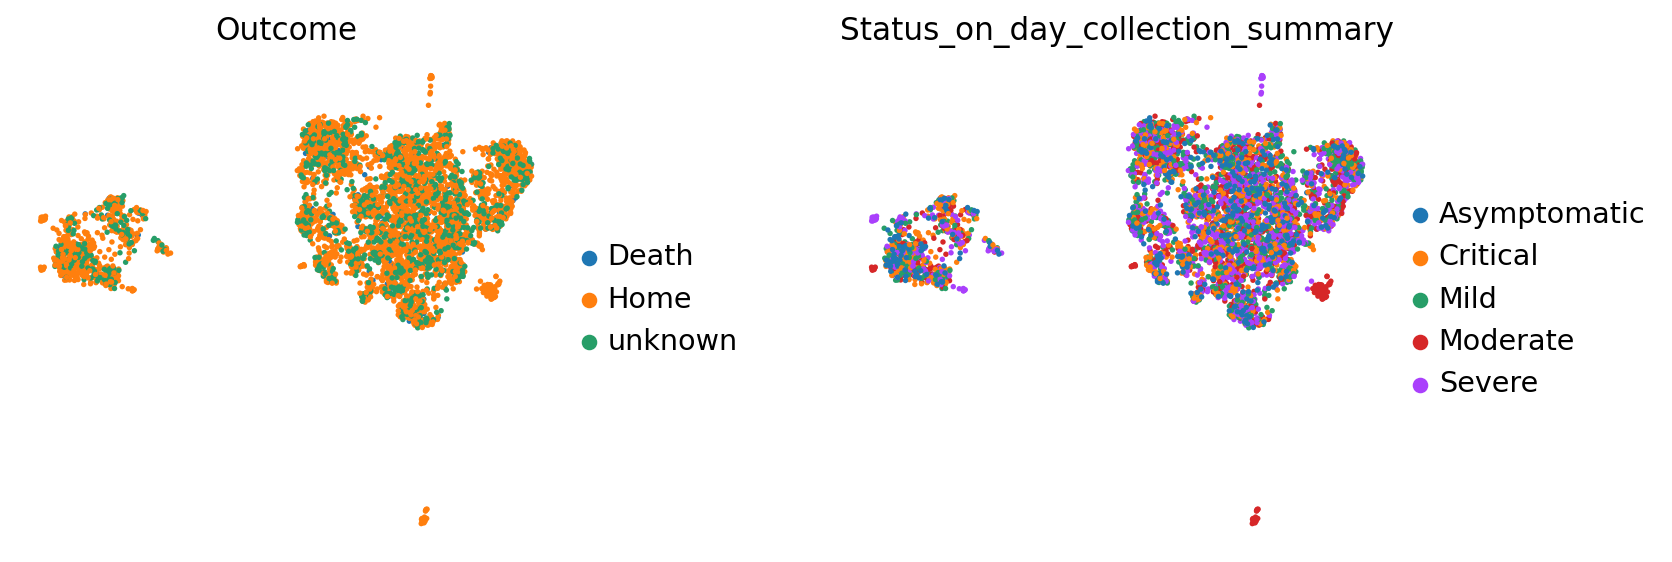

In [6]:
gex = mdata["gex"]

# Align heavy embeddings to gex cell ordering via barcode index
heavy_df = pd.DataFrame(
    mdata["airr"].obsm["X_ibex_heavy"],
    index=mdata["airr"].obs_names,
)
gex.obsm["X_ibex_heavy"] = heavy_df.reindex(gex.obs_names).values

sc.pp.neighbors(gex, use_rep="X_ibex_heavy", n_neighbors=30, metric="cosine")
sc.tl.umap(gex)

sc.pl.umap(gex, color=["Outcome", "Status_on_day_collection_summary"], ncols=2, wspace=0.4)

## 4. Predict COVID-19 outcome from paired BCR embeddings

We concatenate the heavy- and light-chain embeddings into a single feature matrix, then train a regularised logistic regression. `LogisticRegressionCV` selects the regularisation strength via leave-one-out CV on the training data. We evaluate with stratified 5-fold cross-validation and report balanced accuracy (appropriate given the ~18:1 Home/Death imbalance).

In [7]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [8]:
# Align light embeddings to gex cell ordering
light_df = pd.DataFrame(
    mdata["airr"].obsm["X_ibex_light"],
    index=mdata["airr"].obs_names,
)

outcome = mdata["gex"].obs["Outcome"]

X = pd.concat(
    [heavy_df.reindex(outcome.index), light_df.reindex(outcome.index)],
    axis=1,
).values

y = outcome.values

# Keep only cells with a known outcome label
labeled = y != "unknown"
X_clf, y_clf = X[labeled], y[labeled]

print(f"Labeled cells: {labeled.sum()} (Home={(y_clf == 'Home').sum()}, Death={(y_clf == 'Death').sum()})")

Labeled cells: 4025 (Home=3817, Death=208)


In [9]:
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        max_iter=500,
        cv=3,
        class_weight="balanced",
        random_state=42,
    ),
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(pipe, X_clf, y_clf, cv=cv, scoring="balanced_accuracy")

print(f"5-fold CV balanced accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Per-fold: {scores.round(3)}")

5-fold CV balanced accuracy: 0.538 ± 0.024
Per-fold: [0.517 0.567 0.508 0.532 0.565]


## Session info

In [10]:
sc.logging.print_header()

Package,Version
pandas,2.3.2 (2.3.3)
mudata,0.3.8
scibex,0.1.0
scanpy,1.12.1
scirpy,0.24.0
anndata,0.12.16
scikit-learn,1.7.2
numpy,2.3.3
Component,Info
Python,"3.13.7 | packaged by conda-forge | (main, Sep 3 2025, 14:30:35) [GCC 14.3.0]"
